In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## Binary PSI

In [14]:
binary_splice_performances = {
    'BPsiRandomForest': {'MCC': 0.12, 'AUC': 0.56, 'Balanced Accuracy': 0.56, 'F1 Score': 0.41, 'note': 'proper splits'},
    'BPsiHistoneConvSE': {'MCC': 0.20, 'AUC': 0.64, 'Balanced Accuracy': 0.60, 'F1 Score': 0.62, 'note': '+-70bp around the junction -> same for 120bp'},
    'BPsiHistoneConvSE+AR': {'MCC': 0.27, 'AUC': 0.75, 'Balanced Accuracy': 0.67, 'F1 Score': 0.89, 'note': ''},
    'BPsiMergedCellLineSE': {'MCC': 0.36, 'AUC': 0.73, 'Balanced Accuracy': 0.67, 'F1 Score': 0.73, 'note': 'Also conv model'},
    'BPsiESPRNNSE': {'MCC': 0.11, 'AUC': 0.57, 'Balanced Accuracy': 0.55, 'F1 Score': 0.60, 'note': 'model adapted from keras'},
    'BPsiESPRNNNaiveSE': {'MCC': 0.30, 'AUC': 0.71, 'Balanced Accuracy': 0.65, 'F1 Score': 0.70, 'note': 'Naive data splits'},
    'BPsiESPRNNNormSE': {'MCC': 0.34, 'AUC': 0.75, 'Balanced Accuracy': 0.66, 'F1 Score': 0.72, 'note': 'Normalization across all data'},
    'BPsiFullSE': {'MCC': 0.20, 'AUC': 0.64, 'Balanced Accuracy': 0.60, 'F1 Score': 0.67, 'note': 'Full model with seq encoder and attention'},
    'BPsiFullSE+AR': {'MCC': 0.28, 'AUC': 0.79, 'Balanced Accuracy': 0.56, 'F1 Score': 0.95, 'note': ''}
    }

b_psi_df = pd.DataFrame(binary_splice_performances)
b_psi_df

,BPsiRandomForest,BPsiHistoneConvSE,BPsiHistoneConvSE+AR,BPsiMergedCellLineSE,BPsiESPRNNSE,BPsiESPRNNNaiveSE,BPsiESPRNNNormSE,BPsiFullSE,BPsiFullSE+AR
MCC,0.12,0.2,0.27,0.36,0.11,0.3,0.34,0.2,0.28
AUC,0.56,0.64,0.75,0.73,0.57,0.71,0.75,0.64,0.79
Balanced Accuracy,0.56,0.6,0.67,0.67,0.55,0.65,0.66,0.6,0.56
F1 Score,0.41,0.62,0.89,0.73,0.6,0.7,0.72,0.67,0.95
note,proper splits,+-70bp around the junction -> same for 120bp,,Also conv model,model adapted from keras,Naive data splits,Normalization across all data,Full model with seq encoder and attention,


In [ ]:
b_psi_df = b_psi_df.reset_index().melt(id_vars="index", var_name="Model", value_name="Score")
b_psi_df.rename(columns={"index": "Metric"}, inplace=True)

,Metric,Model,Score
0,MCC,BPsiRandomForest,0.12
1,AUC,BPsiRandomForest,0.56
2,Balanced Accuracy,BPsiRandomForest,0.56
3,F1 Score,BPsiRandomForest,0.41
4,note,BPsiRandomForest,proper splits
5,MCC,BPsiHistoneConvSE,0.2
6,AUC,BPsiHistoneConvSE,0.64
7,Balanced Accuracy,BPsiHistoneConvSE,0.6
8,F1 Score,BPsiHistoneConvSE,0.62
9,note,BPsiHistoneConvSE,+-70bp around the junction -> same for 120bp


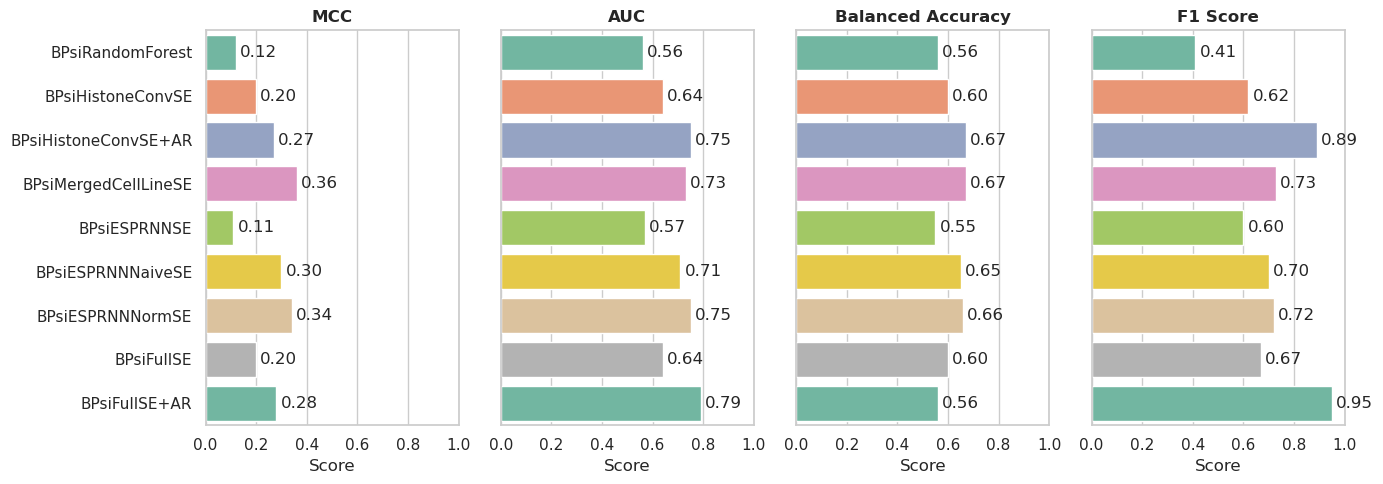

In [ ]:
# plot per metric
palette = sns.color_palette("Set2", n_colors=b_psi_df["Model"].nunique())
fig, ax = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
axes = ax.flatten()

metrics = b_psi_df["Metric"].unique()

for i, metric in enumerate(metrics):
    if metric == 'note':
        continue
    ax = axes[i]
    sns.barplot(
        data=b_psi_df[b_psi_df["Metric"] == metric],
        x="Score", y="Model", ax=ax, orient="h",
        hue="Model", dodge=False, palette=palette
    )
    ax.set_title(metric, fontsize=12, weight="bold")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_ylabel("")  # remove redundant label
    ax.legend([],[], frameon=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)

handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout()
plt.savefig("../images/bpsi_performances.png", dpi=300)
plt.show()

## EPInformer replication

In [35]:
epinformer_performances = {
    'PE-Activity-HiC': {'Pearson r': 0.86, 'group': 'full'},
    'Rep-PE-Activity-HiC': {'Pearson r': 0.86, 'group': 'full'},
    'PE-Activity-HiC-0Enh': {'Pearson r': 0.86, 'group': 'full'},
    
    'PE': {'Pearson r': 0.72, 'group': 'promoter seq'},
    'PE-0Enh': {'Pearson r': 0.64, 'group': 'promoter seq'}, # aligns with their Promoter only test
    
    'PE-Activity': {'Pearson r': 0.84, 'group': 'promoter activity'},
    'PE-Activity-0Enh': {'Pearson r': 0.86, 'group': 'promoter activity'},
    'Activity': {'Pearson r': 0.71, 'group': 'promoter activity'},

    'PE-Activity-HiC-0Enh-0HL': {'Pearson r': 0.85, 'group': 'no half-life'},
}

epinf_df = pd.DataFrame(epinformer_performances)
epinf_df

,PE-Activity-HiC,Rep-PE-Activity-HiC,PE-Activity-HiC-0Enh,PE,PE-0Enh,PE-Activity,PE-Activity-0Enh,Activity,PE-Activity-HiC-0Enh-0HL
Pearson r,0.86,0.86,0.86,0.72,0.64,0.84,0.86,0.71,0.85
group,full,full,full,promoter seq,promoter seq,promoter activity,promoter activity,promoter activity,no half-life


In [36]:
epinf_df = epinf_df.T.reset_index()
epinf_df.rename(columns={"index": "Model"}, inplace=True)
epinf_df

,Model,Pearson r,group
0,PE-Activity-HiC,0.86,full
1,Rep-PE-Activity-HiC,0.86,full
2,PE-Activity-HiC-0Enh,0.86,full
3,PE,0.72,promoter seq
4,PE-0Enh,0.64,promoter seq
5,PE-Activity,0.84,promoter activity
6,PE-Activity-0Enh,0.86,promoter activity
7,Activity,0.71,promoter activity
8,PE-Activity-HiC-0Enh-0HL,0.85,no half-life


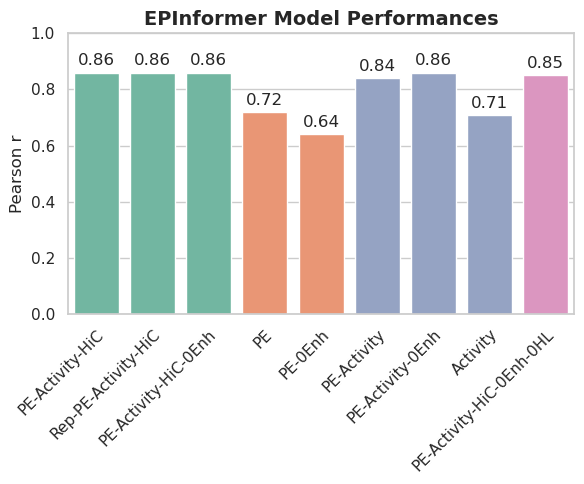

In [37]:
palette = sns.color_palette("Set2", n_colors=epinf_df["group"].nunique())
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.barplot(
    data=epinf_df,
    x="Model", y="Pearson r", ax=ax, orient="v",
    hue="group", dodge=False, palette=palette
)
ax.set_title("EPInformer Model Performances", fontsize=14, weight="bold")
ax.set_ylim(0, 1)
#ax.set_xlabel("Pearson r")
ax.set_xlabel("")  # remove redundant label
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
    label.set_rotation_mode('anchor')
ax.legend([],[], frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)
plt.tight_layout()
plt.savefig("../images/epinformer_performances.png", dpi=300)
plt.show()

In [49]:
response = "../data/GM12878_K562_18377_gene_expr_fromXpresso.csv"
response_df = pd.read_csv(response, index_col=0)
response_df = response_df[['Actual_K562']]

activity_k562 = pd.read_csv('../data/IHEC-ChIP-Seq-Histone-Signals/PromotersK562.H3K27ac.tab', sep='\t', names=['gene_id', 'size', 'covered', 'sum', 'mean0', 'mean'])
# drop rows where covered is less than 1000
activity_k562 = activity_k562[activity_k562['covered'] >= 1000]
activity_k562 = activity_k562[['gene_id', 'mean']]

merged_df = response_df.merge(activity_k562, left_index=True, right_on='gene_id', how='inner')
merged_df.rename(columns={'mean': 'H3K27ac_activity'}, inplace=True)
merged_df

,Actual_K562,gene_id,H3K27ac_activity
18043,-0.638913,ENSG00000000003,0.272761
18042,-1.146680,ENSG00000000005,0.194351
16886,1.529660,ENSG00000000419,21.547500
1419,0.608184,ENSG00000000457,26.697300
1418,1.038466,ENSG00000000460,18.810500
...,...,...,...
16744,1.831873,ENSG00000259399,7.191920
12037,-0.068791,ENSG00000259431,15.745600
12980,0.148647,ENSG00000259511,0.113938
10548,-1.170504,ENSG00000259571,0.000000


In [ ]:
# mean expression
mean_expr = merged_df['Actual_K562'].mean()
mean_expr

np.float64(2.580823787880239e-05)

In [50]:
se_events = pd.read_csv('../data/psi_response.csv')
se_events = se_events[se_events['event_id'].str.contains(';SE:')]
se_genes = set(se_events['gene_id'].unique())

/tmp/ipykernel_3682600/1772586438.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


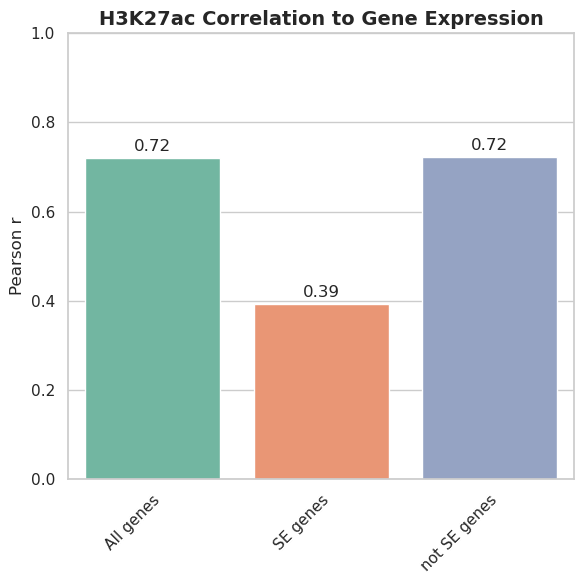

In [59]:
# calculate pearson correlation
from scipy.stats import pearsonr
pearson_r, p_value = pearsonr(merged_df['Actual_K562'], merged_df['H3K27ac_activity'])

# do the same but split for SE and non-SE genes
merged_df_se = merged_df[merged_df['gene_id'].isin(se_genes)]
pearson_r_se, p_value_se = pearsonr(merged_df_se['Actual_K562'], merged_df_se['H3K27ac_activity'])

merged_df_no_se = merged_df[~merged_df['gene_id'].isin(se_genes)]
pearson_r_no_se, p_value_no_se = pearsonr(merged_df_no_se['Actual_K562'], merged_df_no_se['H3K27ac_activity'])

# barplot time
correlation_df = pd.DataFrame({
    'Gene Type': ['All genes', 'SE genes', 'not SE genes'],
    'Pearson r': [pearson_r, pearson_r_se, pearson_r_no_se]
})

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.barplot(
    data=correlation_df,
    x="Gene Type", y="Pearson r", ax=ax, orient="v", legend=False,
    palette="Set2"
)
ax.set_title("H3K27ac Correlation to Gene Expression", fontsize=14, weight="bold")
ax.set_ylim(0, 1)
ax.set_xlabel("")  # remove redundant label
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
    label.set_rotation_mode('anchor')
ax.tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)
plt.tight_layout()
# plt.savefig("../images/k562_activity_expression_correlation.png", dpi=300)
plt.show()

In [61]:
SS_tot_all = np.sum((merged_df['Actual_K562'] - merged_df['Actual_K562'].mean())**2)
SS_tot_se = np.sum((merged_df_se['Actual_K562'] - merged_df_se['Actual_K562'].mean())**2)
SS_tot_no_se = np.sum((merged_df_no_se['Actual_K562'] - merged_df_no_se['Actual_K562'].mean())**2)

SS_tot_all, SS_tot_se, SS_tot_no_se

(np.float64(18376.775072630237),
 np.float64(888.5448834103196),
 np.float64(13398.267727759456))